In [1]:
# !pip install playwright
!pip install nest_asyncio
# !playwright install chromium
# !pip install matplotlib

In [2]:
import nest_asyncio
nest_asyncio.apply()

In [8]:
from rightmove_analysis import run

# Change location here whenever you want
df = run(location="Caversham", radius=1.0, max_pages=10)


Resolving location: 'Caversham'...
  Found: Caversham, Reading, Berkshire (REGION%5E5864)

Fetching listings (radius=1.0 mi, up to 10 pages)...

------------------------------------------------------------
  RIGHTMOVE ANALYSIS -- CAVERSHAM, READING, BERKSHIRE
------------------------------------------------------------
  Total listings fetched : 50
  Listings with price    : 50
  Listings with sq ft    : 2 (4%)

  PRICES (all types)
    Median :    280,000
    Mean   :    340,416
    Min    :     80,000
    Max    :    795,000

  MEDIAN PRICE BY BEDROOMS
    1-bed :    159,000  (n=12)
    2-bed :    250,000  (n=20)
    3-bed :    425,000  (n=10)
    4-bed :    747,475  (n=4)
    5-bed :    715,000  (n=2)
    6-bed :    450,000  (n=2)

  MEDIAN PRICE BY TYPE
    Detached              :    747,475  (n=4)
    Semi-Detached         :    550,000  (n=6)
    Terraced              :    340,000  (n=16)
    Apartment             :    193,750  (n=20)
    Flat                  :    184,000  (n=4)

In [ ]:
from requests.auth import HTTPBasicAuth
import requests

EPC_EMAIL = "nombody49@hotmail.com"
EPC_KEY = "rescinded"
EPC_AUTH = HTTPBasicAuth(EPC_EMAIL, EPC_KEY)

# Pull first page of Reading EPC records
response = requests.get(
    "https://epc.opendatacommunities.org/api/v1/domestic/search",
    auth=EPC_AUTH,
    params={"local-authority": "E06000038", "size": 25},
    headers={"Accept": "application/json"}
)
data = response.json()
rows = data.get("rows", [])
print(f"Records on first page: {len(rows)}")
print(f"Total available: {data.get('total', 'unknown')}")
if rows:
    print("\nSample record:")
    print("Address    :", rows[0].get("address"))
    print("Postcode   :", rows[0].get("postcode"))
    print("Floor area :", rows[0].get("total-floor-area"))
    print("Type       :", rows[0].get("property-type"))

Records on first page: 25
Total available: unknown

Sample record:
Address    : 11 Basildon House, Iliffe Close
Postcode   : RG1 2QN
Floor area : 58.0
Type       : Flat


In [18]:
# Extract street name from address e.g. "Lomond Drive, Kettering NN15" -> "Lomond Drive"
def extract_street(address):
    if not address:
        return None
    # Take everything before the first comma
    street = address.split(",")[0].strip()
    # Strip any leading postcode fragment e.g. "NN15 Silverstone Road" -> "Silverstone Road"
    street = re.sub(r'^[A-Z]{1,2}\d{1,2}\s+', '', street, flags=re.IGNORECASE)
    return street

df["street"] = df["address"].apply(extract_street)
print(df[["address", "street"]].head(10))

                                        address            street
0  Conisboro Avenue, Caversham Heights, Reading  Conisboro Avenue
1  Conisboro Avenue, Caversham Heights, Reading  Conisboro Avenue
2                Grovelands Road, Reading, RG30   Grovelands Road
3                Grovelands Road, Reading, RG30   Grovelands Road
4    East View Place, East Street, Reading, RG1   East View Place
5    East View Place, East Street, Reading, RG1   East View Place
6    East View Place, East Street, Reading, RG1   East View Place
7    East View Place, East Street, Reading, RG1   East View Place
8       Quadrant Court, Jubilee Square, Reading    Quadrant Court
9       Quadrant Court, Jubilee Square, Reading    Quadrant Court


In [23]:
import pandas as pd
import time

def fetch_all_epc(local_authority: str, auth) -> pd.DataFrame:
    all_rows = []
    search_after = None
    page = 1

    while True:
        params = {"local-authority": local_authority, "size": 5000}
        if search_after:
            params["search-after"] = search_after

        resp = requests.get(
            "https://epc.opendatacommunities.org/api/v1/domestic/search",
            auth=auth,
            params=params,
            headers={"Accept": "application/json"}
        )
        data = resp.json()
        rows = data.get("rows", [])
        all_rows.extend(rows)
        print(f"  Page {page}: {len(rows)} records (total so far: {len(all_rows)})")

        search_after = resp.headers.get("X-Next-Search-After")
        if not search_after or not rows:
            break

        page += 1
        time.sleep(0.5)

    df_epc = pd.DataFrame(all_rows)[["address", "postcode", "total-floor-area", "property-type"]]
    df_epc["total-floor-area"] = pd.to_numeric(df_epc["total-floor-area"], errors="coerce")
    df_epc["street"] = df_epc["address"].apply(
        lambda x: x.split(",")[-1].strip() if pd.notna(x) else None
    )
    return df_epc

print("Fetching EPC records for Reading...")
df_epc = fetch_all_epc("E06000038", EPC_AUTH)
print(f"\nTotal EPC records: {len(df_epc)}")
print(df_epc.head())

Fetching EPC records for Reading...
  Page 1: 5000 records (total so far: 5000)
  Page 2: 5000 records (total so far: 10000)
  Page 3: 5000 records (total so far: 15000)
  Page 4: 5000 records (total so far: 20000)
  Page 5: 5000 records (total so far: 25000)
  Page 6: 5000 records (total so far: 30000)
  Page 7: 5000 records (total so far: 35000)
  Page 8: 5000 records (total so far: 40000)
  Page 9: 5000 records (total so far: 45000)
  Page 10: 5000 records (total so far: 50000)
  Page 11: 5000 records (total so far: 55000)
  Page 12: 5000 records (total so far: 60000)
  Page 13: 5000 records (total so far: 65000)
  Page 14: 5000 records (total so far: 70000)
  Page 15: 5000 records (total so far: 75000)
  Page 16: 5000 records (total so far: 80000)
  Page 17: 5000 records (total so far: 85000)
  Page 18: 3244 records (total so far: 88244)
  Page 19: 0 records (total so far: 88244)

Total EPC records: 88244
                           address  postcode  total-floor-area property-type 

In [25]:
df_epc

,address,postcode,total-floor-area,property-type,street
0,"11 Basildon House, Iliffe Close",RG1 2QN,58.000,Flat,Iliffe Close
1,80 Birdhill Avenue,RG2 7JU,96.000,House,80 Birdhill Avenue
2,"Flat 3, 208 Tilehurst Road",RG30 2LY,57.000,Flat,208 Tilehurst Road
3,"Flat 4, 5 Addington Road",RG1 5LT,40.000,Flat,5 Addington Road
4,"Top Floor Flat, 9 Mason Street",RG1 7PD,35.000,Flat,9 Mason Street
...,...,...,...,...,...
88239,"Flat 3, 40 Hamilton Road",RG1 5RD,25.310,Flat,40 Hamilton Road
88240,"65 Quadrant Court, Jubilee Square",RG1 2GW,67.420,House,Jubilee Square
88241,"Flat 3, 115 Southampton Street",RG1 2QZ,24.089,Flat,115 Southampton Street
88242,"27, Surrey Road",RG2 0EU,74.880,House,Surrey Road


In [31]:
df_epc[df_epc['postcode']=='RG1 8GB']

,address,postcode,total-floor-area,property-type,street
16493,4 Cox Terrace,RG1 8GB,113.0,House,4 Cox Terrace
16704,8 Cox Terrace,RG1 8GB,113.0,House,8 Cox Terrace
17045,6 Cox Terrace,RG1 8GB,113.0,House,6 Cox Terrace
17187,10 Cox Terrace,RG1 8GB,113.0,House,10 Cox Terrace
17234,2 Cox Terrace,RG1 8GB,113.0,House,2 Cox Terrace


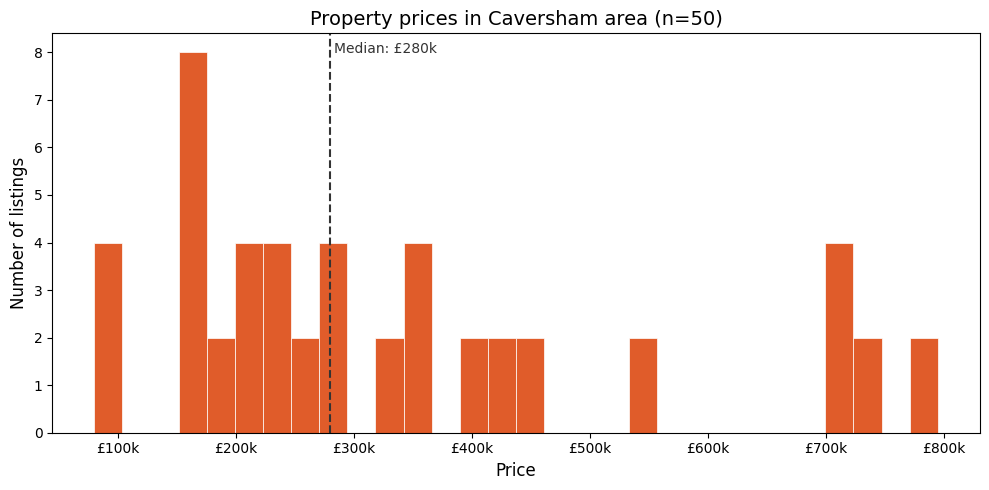

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

prices = df["price_gbp"].dropna()

ax.hist(prices, bins=30, color="#e05c2a", edgecolor="white", linewidth=0.5)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}k"))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax.set_xlabel("Price", fontsize=12)
ax.set_ylabel("Number of listings", fontsize=12)
ax.set_title(f"Property prices in Caversham area (n={len(prices)})", fontsize=14)

# Add median line
median = prices.median()
ax.axvline(median, color="#333333", linestyle="--", linewidth=1.5)
ax.text(median * 1.01, ax.get_ylim()[1] * 0.95, f"Median: £{median/1000:.0f}k",
        fontsize=10, color="#333333")

plt.tight_layout()
plt.show()

In [53]:
df_epc['square_feet'] = np.where(df_epc['total-floor-area']*10.7639>5000,5000,df_epc['total-floor-area']*10.7639)

In [54]:
df_epc.square_feet.max()

np.float64(5000.0)

In [59]:
df_epc_houses = df_epc[df_epc['property-type'] == 'House']

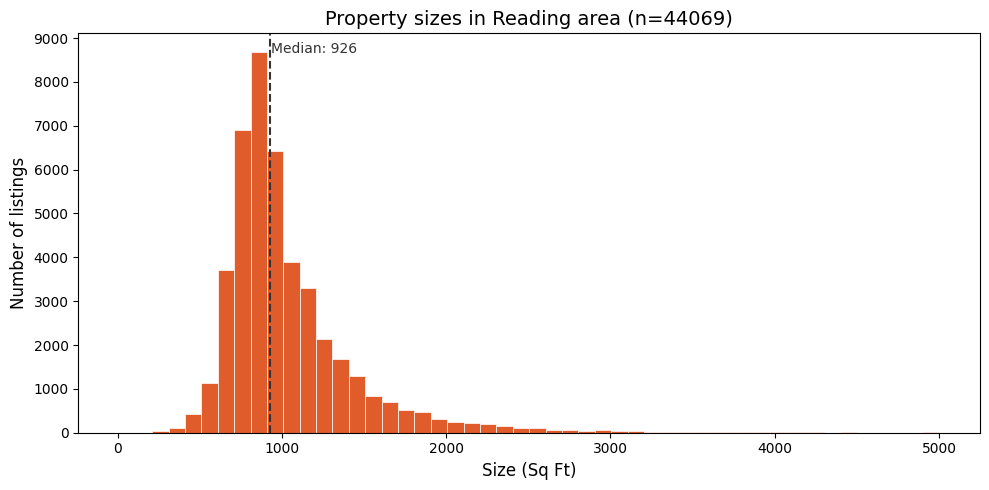

In [60]:

fig, ax = plt.subplots(figsize=(10, 5))

sizes = df_epc_houses["square_feet"].dropna()

ax.hist(sizes, bins=50, color="#e05c2a", edgecolor="white", linewidth=0.5)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax.set_xlabel("Size (Sq Ft)", fontsize=12)
ax.set_ylabel("Number of listings", fontsize=12)
ax.set_title(f"Property sizes in Reading area (n={len(sizes)})", fontsize=14)

# Add median line
median = sizes.median()
ax.axvline(median, color="#333333", linestyle="--", linewidth=1.5)
ax.text(median * 1.01, ax.get_ylim()[1] * 0.95, f"Median: {median:.0f}",
        fontsize=10, color="#333333")

plt.tight_layout()
plt.show()